# PCA In-Class Exercises

Exercises accompanying the lectures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1:  Computing PCs Manually on a Synthetic Dataset

We begin by showing how to compute and visualize PCs manually on a simple 2-dim synthentic data set.  First, run the following code to generate 100 samples of synthetic data.  Each data point has `d=2` dimensions.

In [2]:
p = 0.5
std = 0.2
s = np.array([2,1])
d = 2
ns = 100

U = np.random.normal(0,std,(ns,d))
v = np.random.uniform(0,1,ns)
X = U + (v < p)[:,None]*s[None,:]

Create a scatter plot of the data of the two features of the data, `X[:,0]` and `X[:,1]`.

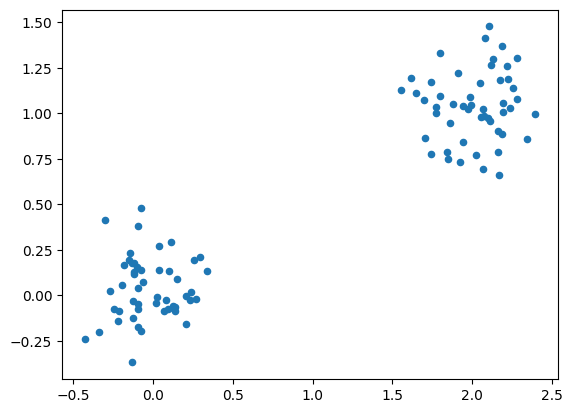

In [3]:
# TODO
plt.scatter(X[:,0], X[:,1], s=20)

We now manually compute the first principal component.  Later, we will find a faster way using an SVD.

*  Compute `xm` the mean of each of the two features.
*  Compute `Xm`, the matrix of data samples with the means removed
*  Compute the covariance matrix `Q = (1/ns)*Xm.T.dot(Xm)`
*  Compute the eigenvalues `lam` and eigenvectors `V` of `Q` using the `np.linalg.eigh(Q)` command.
*  Set `v0` be the eigenvector corresponding to the largest eigenvalue.  This is is the first PC.

In [4]:
# TODO
xm = np.mean(X)
Xm = X - xm
Q = (1/ns)*Xm.T.dot(Xm)
lam,V = np.linalg.eigh(Q)
v0 = V[:,np.argmax(lam)]

Compute the projection of the data vectors onto the first PC with the following:
    
    z[i] = Xm[i,:].dot(v0)
    Xhat[i,:] = xm + v0*z[i]
    
Note that we remove the mean when projecting and then add it back.
Create a scatter plot with:

*  The original data points `X[:,0], X[:,1]` in one color
*  The projected data points `Xhat[:,0], Xhat[:,1]` in a second color

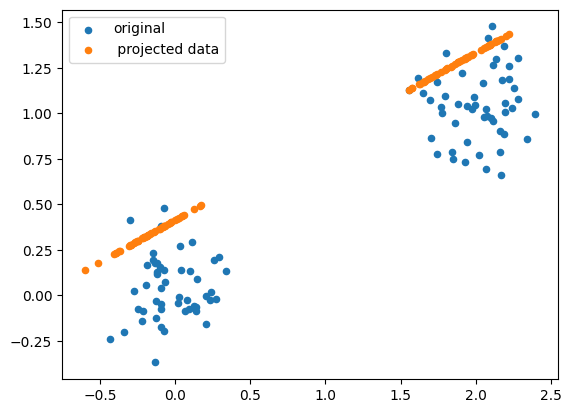

In [7]:
# TODO
z = Xm.dot(v0)
Xhat = xm + np.outer(z,v0)
plt.scatter(X[:,0],X[:,1],s = 20, label = 'original')
plt.scatter(Xhat[:,0],Xhat[:,1],s = 20, label= ' projected data')
plt.legend()

## Exercise 2:  Computing the Approximation Error

We now verify the approximation errors.  For each `k`:

*  Compute `Z`, the PC coefficients of `X`
*  Compute `Xhat`, the PC approximation of `X` using `k` PC coefficients
*  Compute the approximation error, `err[k]` the average error `1/ns sum_{ij} (X[i,j]-Xhat[i,j])**2)`
*  Compute the expected approximation error, `err_pred[k]` the expected approximation error based on the eigenvalues `lam`.

Remember you will need to sort the eigenvalues in descending order.  You can use the command

     I = np.argsort(lam)[::-1]

In [11]:
# Sort the eigenvalues in descending order
I = np.argsort(lam)[::-1]

# TODO
err = np.zeros(d)
err_pred = np.zeros(d)
for k in range(d):
  err_pred[k]= np.sum(lam[I[k+1:]])
for k in range(d):
  Vk = V [:, I[:k]]
  Zk = Xm.dot(Vk)
  Xhat_k = xm + Zk.dot(Vk.T)
  err[k] = np.mean((X-Xhat_k)**2)
#   err_pred = ...

## Exercise 3:  Computing the PCA via the SVD

*  Compute the matrix `A = 1/np.sqrt(ns)*Xm`
*  Compute the economy SVD of `A` with the `np.linalg.svd()` command.  Use `full_matrices=False` option.  Print the dimensions of the components of the SVD

In [12]:
# TODO
ns = Xm.shape[1]
A = 1/np.sqrt(ns)*Xm
U, s, Vtr = np.linalg.svd(A, full_matrices = False)
print("A shape", A.shape)
print("U shaoe", U.shape)
print("s shape", s.shape)
print("Vtr shape", Vtr.shape)

A shape (100, 2)
U shaoe (100, 2)
s shape (2,)
Vtr shape (2, 2)


Verify that the singular values squared `s**2` match the eigenvalues of the covariance matrix `Q`.

In [17]:
# TODO
Q = A @ A.T
eigvals, eigvecs = np.linalg.eigh(Q)
eigvals_sorted = np.flip(eigvals)

print(s**2)
print(eigvals_sorted)


[66.66564947  6.15680584]
[ 6.66656495e+01  6.15680584e+00  2.48370471e-14  1.75611348e-14
  1.27062390e-14  1.18412098e-14  1.14911688e-14  9.23144383e-15
  8.88288322e-15  8.37611307e-15  7.88183548e-15  6.66849486e-15
  6.57223705e-15  4.85277898e-15  4.33757937e-15  3.79571780e-15
  3.67267378e-15  3.04440167e-15  2.99622648e-15  2.81462320e-15
  2.76738258e-15  2.51217787e-15  2.18306835e-15  1.99686022e-15
  1.75217349e-15  1.68204858e-15  1.35872436e-15  1.30505072e-15
  1.29204258e-15  1.24132610e-15  1.07251207e-15  1.05316235e-15
  1.00836250e-15  9.54280823e-16  7.94121059e-16  6.44256139e-16
  6.10280357e-16  5.08327712e-16  4.97590863e-16  4.33891548e-16
  4.26849132e-16  4.10236561e-16  3.68408619e-16  2.92489988e-16
  2.62363194e-16  1.67011289e-16  1.63885290e-16  1.49521212e-16
  8.75701828e-17  3.29212260e-17 -1.87262610e-17 -5.33586802e-17
 -9.76271539e-17 -1.16712478e-16 -1.21440707e-16 -1.99320495e-16
 -2.55142206e-16 -3.44636994e-16 -4.65404687e-16 -4.84615129e-16

Compute the coefficients, `Zhat` of `X` on the PC vectors.  Make sure they match `Z` computed above (up to some sign and permutations).

In [18]:
# TODO
Zhat = U.T @ Xm
print(Zhat.shape)
print(Zhat)

(2, 2)
[[-10.48848841  -4.82937985]
 [  1.46763492  -3.18742206]]
